In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve 

%matplotlib inline

In [3]:
df = pd.read_csv('../data/raw/Telco_Customer_Churn.csv')

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [5]:
print("Daten geladen:", df.shape)

Daten geladen: (7043, 21)


## Encoding

In [6]:
df_model = df.copy()

df_model = df_model.drop(['customerID'], axis=1)

le = LabelEncoder()

cat_cols = df_model.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))


print("Encoding vollständig\n", df_model.dtypes)

Encoding vollständig
 gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


/var/folders/dn/zzfq27f910d7myxhfgxw0w_r0000gn/T/ipykernel_7507/1628649243.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include=['object']).columns


# Features und Target trennen

In [7]:
x = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print("Merkmale (X):", x.shape)
print("Zielvariable (y):", y.shape)
print("\nSpalten von X:",x.columns.tolist())

Merkmale (X): (7043, 19)
Zielvariable (y): (7043,)

Spalten von X: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


## Train und Test Splitting

In [8]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Trainingsdaten:", X_train.shape, y_train.shape)
print("Testdaten:", X_test.shape, y_test.shape)
print("\nChurn-Verteilung in den Trainingsdaten:\n", y_train.value_counts(normalize=True).round(2)*100)

Trainingsdaten: (5634, 19) (5634,)
Testdaten: (1409, 19) (1409,)

Churn-Verteilung in den Trainingsdaten:
 Churn
0    73.0
1    27.0
Name: proportion, dtype: float64


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Skalierung abgeschlossen. Beispielwerte:\n", X_train_scaled[:5])

Skalierung abgeschlossen. Beispielwerte:
 [[ 0.99433624 -0.44177295 -0.96923413 -0.65155653  0.10237124 -3.01309011
   0.05525321 -1.18311574 -0.91955823 -1.0405346   1.24087411 -0.92792775
   1.13544459  1.13181864 -0.82777445 -1.20265302  0.40093316 -0.52197565
  -0.2622572 ]
 [ 0.99433624 -0.44177295  1.03174245  1.53478624 -0.71174346  0.3318852
  -0.99998941  0.17417892  1.40366647 -1.0405346  -1.02969579 -0.92792775
  -1.12261923 -1.12620764 -0.82777445 -1.20265302  1.33627784  0.33747781
  -0.50363479]
 [ 0.99433624 -0.44177295  1.03174245  1.53478624 -0.79315493 -3.01309011
   0.05525321 -1.18311574  1.40366647  1.22730754 -1.02969579  1.38942373
  -1.12261923 -1.12620764  1.56938887 -1.20265302  1.33627784 -0.80901319
  -0.74988292]
 [-1.00569602 -0.44177295  1.03174245 -0.65155653 -0.26398038  0.3318852
  -0.99998941 -1.18311574 -0.91955823  1.22730754  1.24087411 -0.92792775
   1.13544459  1.13181864  1.56938887  0.83149502 -0.53441153  0.28438416
  -0.17272239]
 [ 0.9943362

In [10]:
modell = LogisticRegression(max_iter=1000 ,random_state=42)
modell.fit(X_train_scaled, y_train)

y_pred = modell.predict(X_test_scaled)
y_pred_prob = modell.predict_proba(X_test_scaled)[:,1 ]

print("Traning abgeschlossen")
print("\n Erste 10 Vorhersagen:", y_pred[:10])
print("\n Erste 10 Vorhersagewahrscheinlichkeiten:", y_pred_prob[:10])
print("\n Tatsächliche werte:", y_test.values[:10])

Traning abgeschlossen

 Erste 10 Vorhersagen: [0 1 0 0 0 1 0 0 0 0]

 Erste 10 Vorhersagewahrscheinlichkeiten: [0.04581096 0.73717892 0.07566725 0.33657421 0.02107975 0.66140652
 0.46073625 0.13109706 0.00271722 0.35483276]

 Tatsächliche werte: [0 0 0 0 0 0 0 0 0 1]


## Evaluierung des Modells

In [11]:
print("\nKlassifikationsbericht:\n", classification_report(y_test, y_pred, target_names=['Kein Churn', 'Churn']))

auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC AUC Score: {auc:.3f}")


Klassifikationsbericht:
               precision    recall  f1-score   support

  Kein Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


ROC AUC Score: 0.840


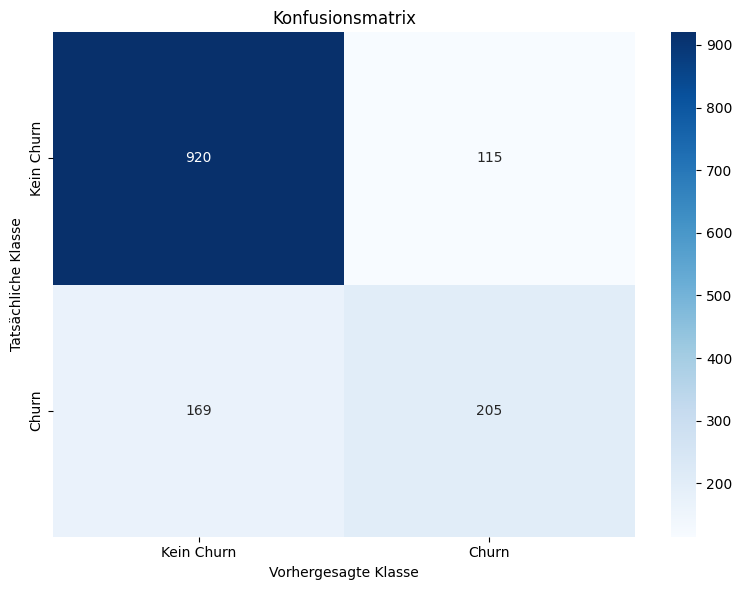

In [12]:
fig, ax = plt.subplots(figsize=(8,6))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['Kein Churn', 'Churn'], yticklabels=['Kein Churn', 'Churn'])

ax.set_title('Konfusionsmatrix')
ax.set_xlabel('Vorhergesagte Klasse')
ax.set_ylabel('Tatsächliche Klasse')

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png')
plt.show()



## Modell Ergebnisse – Logistic Regression

| Metrik | Wert |
|--------|------|
| Accuracy | 80% |
| AUC-ROC | 0.84 |
| Precision (Churn) | 64% |
| Recall (Churn) | 55% |

Das Modell erkennt 55% aller echten Churner korrekt.
169 Churner wurden nicht erkannt. Auf jeden Fall Potenzial für Verbesserung
durch fortgeschrittenere Modelle wie Random Forest oder XGBoost. Coming Soon...

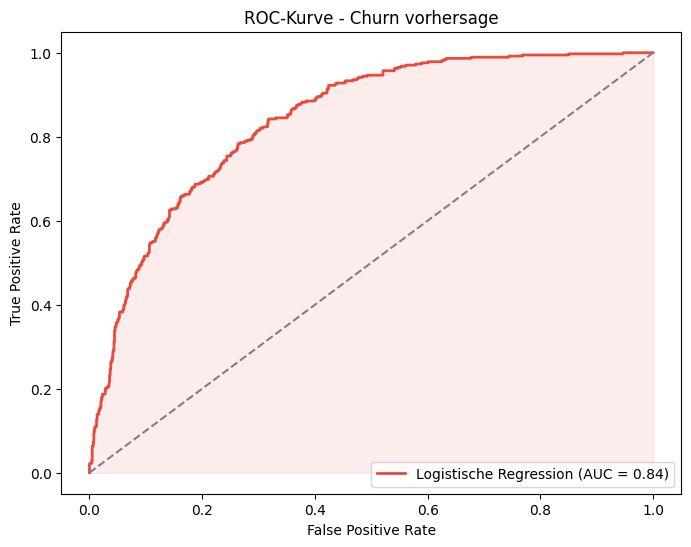

In [13]:
fig, ax = plt.subplots(figsize=(8,6))

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

ax.plot(fpr, tpr, linewidth=2, color='#e74c3c', label=f'Logistische Regression (AUC = {auc:.2f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray')

ax.set_title('ROC-Kurve - Churn vorhersage')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')

plt.tight_layout
plt.savefig('../reports/figures/roc_curve.png')
plt.show()


## Vergleich ML-Modelle (Logistics Regression, XGBoost, Random Forest)

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier

In [20]:
modelle = {
    'Logistische Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

ergebnisse = {}

for name, modell in modelle.items():
    modell.fit(X_train_scaled, y_train)
    y_pred = modell.predict(X_test_scaled)
    y_pred_prob = modell.predict_proba(X_test_scaled)[:,1 ]
    
    auc = roc_auc_score(y_test, y_pred_prob)
    report = classification_report(y_test, y_pred, target_names=['Kein Churn', 'Churn'], output_dict=True)
    ergebnisse[name] = {
        'AUC' : auc,
        'Precision' : report['Churn']['precision'],
        'Recall' : report['Churn']['recall'],
        'F1-Score' : report['Churn']['f1-score'],
        'Accuracy' : report['accuracy']
    }
    
    print(f"\n{name} - ROC AUC Score: {auc:.3f}")

    ergebnisse_df = pd.DataFrame(ergebnisse).T.round(3)
    print(classification_report(y_test, y_pred, target_names=['Kein Churn', 'Churn']))


Logistische Regression - ROC AUC Score: 0.840
              precision    recall  f1-score   support

  Kein Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Random Forest - ROC AUC Score: 0.825
              precision    recall  f1-score   support

  Kein Churn       0.84      0.90      0.87      1035
       Churn       0.64      0.52      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


XGBoost - ROC AUC Score: 0.823
              precision    recall  f1-score   support

  Kein Churn       0.83      0.88      0.86      1035
       Churn       0.61      0.51      0.56       374

    accuracy                           0.78      1409
   macro av

## ML-Modell Vergleich

| Modell | AUC-ROC |
|--------|---------|
| Logistic Regression | 0.840 ✅ |
| Random Forest | 0.825 |
| XGBoost | 0.823 |

**Gewinner: Logistic Regression**

Trotz einfacherer Architektur erzielt Logistic Regression
den besten AUC-ROC Score. Bei diesem Dataset mit ~7000 Zeilen
und vielen kategorischen Features ist ein lineares Modell
optimal – komplexere Modelle overfitten leicht.

**Finales Modell:** Logistic Regression mit AUC-ROC 0.84